# Homework — Filters, Gaussian blur and edge detection (MILK10k)

**Course:** Computer Vision and Speech Recognition — EADA
**Student:** Kristof Papp

Three exercises:
1. **Learned filters**: apply the filters a CNN learned (first layer of a pretrained ResNet-18) to MILK10k
   images from different diagnosis classes and compare malignant vs benign lesions.
2. **Gaussian blur**: what `sigma` controls in `scipy.ndimage.gaussian_filter`, with experiments.
3. **Canny edge detection**: my own implementation, applied to a MILK10k image and compared with Sobel.

**How to run:** the data folder is set in ONE place (the configuration cell below). By default it is
`../data/milk10k` (relative to this notebook). To use another location, set the environment variable
`MILK10K_DIR` before starting Jupyter. Then use *Restart & Run All*. The first run downloads the
ResNet-18 weights (~45 MB) once.

**Code (GitHub):** REPLACE_WITH_NOTEBOOK_LINK

## 0. Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi
import torch
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

# ---- configuration (the only place to change paths) ----
DATA_DIR = Path(os.environ.get("MILK10K_DIR", "../data/milk10k"))
IMG_DIR = DATA_DIR / "images"
IMG_SIZE = 384          # images are resized to this (square) before filtering, so all are comparable
SEED = 42               # fixed so the same images are picked every run
FIG_DIR = Path("figures_filters")
FIG_DIR.mkdir(exist_ok=True)

assert (DATA_DIR / "metadata.csv").exists(), f"metadata.csv not found in {DATA_DIR.resolve()}"
print("data folder:", DATA_DIR.resolve())

data folder: C:\Users\krisi\milk10k-cv-course\data\milk10k


### Load the labels
`metadata.csv` has one row per image (with `diagnosis_1` = Benign / Malignant / Indeterminate);
`training_gt.csv` has the one-hot 11-class label per lesion. I keep only **dermoscopic** images, so every
lesion appears once and all images come from the same kind of camera.

In [2]:
meta = pd.read_csv(DATA_DIR / "metadata.csv")
gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")
classes = [c for c in gt.columns if c != "lesion_id"]
gt["dx"] = gt[classes].idxmax(axis=1)          # one-hot -> class name

derm = meta[meta["image_type"] == "dermoscopic"].merge(gt[["lesion_id", "dx"]], on="lesion_id")
print(len(derm), "dermoscopic images")
print(derm.groupby(["diagnosis_1", "dx"]).size().to_string())

5240 dermoscopic images
diagnosis_1    dx     
Benign         BEN_OTH      44
               BKL         544
               DF           52
               INF          50
               NV          746
               VASC         47
Indeterminate  AKIEC       123
Malignant      AKIEC       180
               BCC        2522
               MAL_OTH       9
               MEL         450
               SCCKA       473


### Helper functions

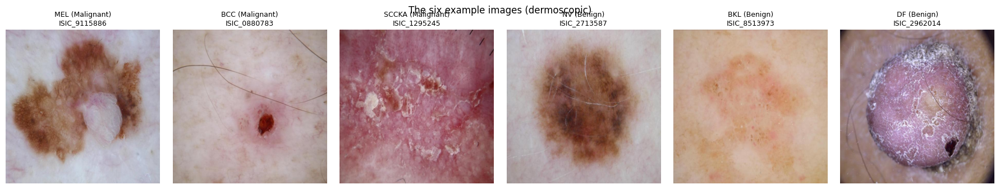

In [3]:
def load_rgb(isic_id, size=IMG_SIZE):
    """Load one image as float RGB in [0, 1], resized to size x size."""
    img = Image.open(IMG_DIR / f"{isic_id}.jpg").convert("RGB").resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


def to_gray(rgb):
    """RGB [0,1] -> grayscale [0,1] with the standard luminance weights."""
    return rgb @ np.array([0.299, 0.587, 0.114], dtype=np.float32)


# One example image per class: 3 malignant classes and 3 benign classes.
MALIGNANT_CLASSES = ["MEL", "BCC", "SCCKA"]   # melanoma, basal cell carcinoma, squamous cell carcinoma
BENIGN_CLASSES = ["NV", "BKL", "DF"]          # nevus (mole), benign keratosis, dermatofibroma

examples = []
for dx in MALIGNANT_CLASSES + BENIGN_CLASSES:
    row = derm[(derm["dx"] == dx) & (derm["diagnosis_1"] != "Indeterminate")].sample(1, random_state=SEED).iloc[0]
    examples.append({"isic_id": row["isic_id"], "dx": dx, "group": row["diagnosis_1"]})
examples = pd.DataFrame(examples)
images = {r.isic_id: load_rgb(r.isic_id) for r in examples.itertuples()}

fig, axes = plt.subplots(1, 6, figsize=(18, 3.4))
for ax, r in zip(axes, examples.itertuples()):
    ax.imshow(images[r.isic_id]); ax.set_title(f"{r.dx} ({r.group})\n{r.isic_id}", fontsize=9); ax.axis("off")
plt.suptitle("The six example images (dermoscopic)")
plt.tight_layout(); plt.savefig(FIG_DIR / "examples.png", dpi=120); plt.show()

---
## 1. Exploring learned filters

A CNN learns its own filters during training. The filters of the **first convolutional layer** are the
easiest to interpret, because they work directly on pixels, like the hand-made filters (Sobel, Gaussian)
from class. I use **ResNet-18 pretrained on ImageNet** (`conv1`: 64 filters of size 7×7×3).

### 1.1 What do the learned filters look like?

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\krisi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


conv1 weights: (64, 3, 7, 7)


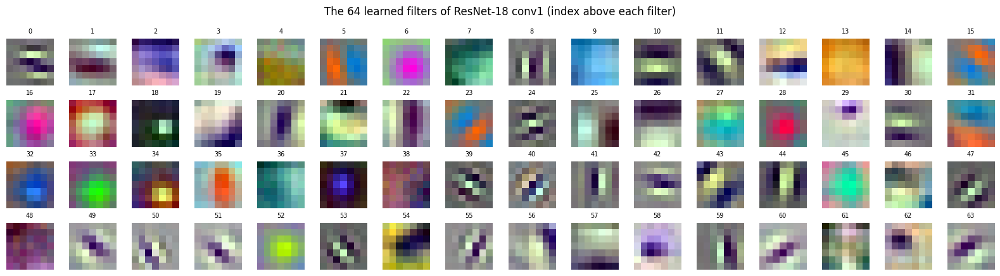

In [4]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights).eval()
W = model.conv1.weight.detach()            # shape (64, 3, 7, 7)
print("conv1 weights:", tuple(W.shape))

# Show each filter as a small RGB image (rescaled to [0,1] for display).
fig, axes = plt.subplots(4, 16, figsize=(16, 4.4))
for i, ax in enumerate(axes.flat):
    f = W[i].permute(1, 2, 0).numpy()
    ax.imshow((f - f.min()) / (f.max() - f.min() + 1e-8), interpolation="nearest")
    ax.set_title(str(i), fontsize=7); ax.axis("off")
plt.suptitle("The 64 learned filters of ResNet-18 conv1 (index above each filter)")
plt.tight_layout(); plt.savefig(FIG_DIR / "conv1_filters.png", dpi=120); plt.show()

Most filters fall into three families: **oriented edge detectors** (a dark band next to a light band, at
different angles), **texture / high-frequency detectors** (stripes or checkerboard patterns), and
**colour-blob detectors** (a single colour or a colour contrast, e.g. red vs green). These are almost the same
filters as Sobel / Gabor / colour-opponent filters, but the network learned them from data.

### 1.2 Pick a few filters of each kind
To choose filters objectively instead of by eye, I measure each filter's **colour-ness** (how different its
three colour channels are) and its **frequency** (how much of its energy is in high spatial frequencies).

{'edge': [60, 49, 30], 'texture': [40, 24, 39], 'colour': [45, 27, 31]}


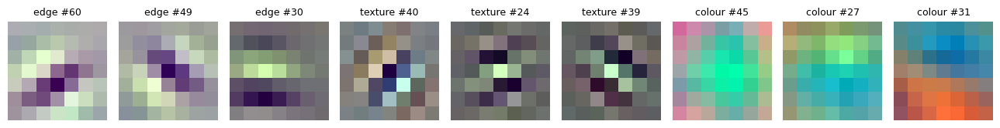

In [5]:
Wn = W.numpy()
gray_part = Wn.mean(axis=1, keepdims=True)                       # what all 3 channels share
colourness = np.abs(Wn - gray_part).sum(axis=(1, 2, 3)) / (np.abs(Wn).sum(axis=(1, 2, 3)) + 1e-8)

def high_freq_ratio(f2d):
    """Share of a 7x7 filter's spectral energy outside the lowest frequencies."""
    spec = np.abs(np.fft.fftshift(np.fft.fft2(f2d, s=(32, 32)))) ** 2
    yy, xx = np.mgrid[-16:16, -16:16]
    return spec[np.hypot(yy, xx) > 6].sum() / (spec.sum() + 1e-8)

freq = np.array([high_freq_ratio(Wn[i].mean(axis=0)) for i in range(64)])
filter_table = pd.DataFrame({"colourness": colourness, "high_freq": freq})

# 3 colour filters = most colourful; among the rest, 3 texture (highest frequency) + 3 edge (middle frequency).
colour_ids = filter_table["colourness"].nlargest(3).index.tolist()
rest = filter_table.drop(colour_ids)
rest = rest[rest["colourness"] < rest["colourness"].median()]     # clearly grey-ish filters
texture_ids = rest["high_freq"].nlargest(3).index.tolist()
edge_ids = rest.drop(texture_ids)["high_freq"].sort_values().iloc[len(rest) // 2 - 1: len(rest) // 2 + 2].index.tolist()
CHOSEN = {"edge": edge_ids, "texture": texture_ids, "colour": colour_ids}
print(CHOSEN)

fig, axes = plt.subplots(1, 9, figsize=(13, 2))
for ax, (kind, i) in zip(axes, [(k, i) for k, ids in CHOSEN.items() for i in ids]):
    f = W[i].permute(1, 2, 0).numpy()
    ax.imshow((f - f.min()) / (f.max() - f.min() + 1e-8), interpolation="nearest")
    ax.set_title(f"{kind} #{i}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "chosen_filters.png", dpi=120); plt.show()

### 1.3 Apply the filters to the six images
The image is normalised exactly as during the network's training (ImageNet mean/std), then convolved with
`conv1` (stride 1 here, so the output keeps the full resolution). I show the **absolute response**: bright =
the filter's pattern is strongly present at that spot.

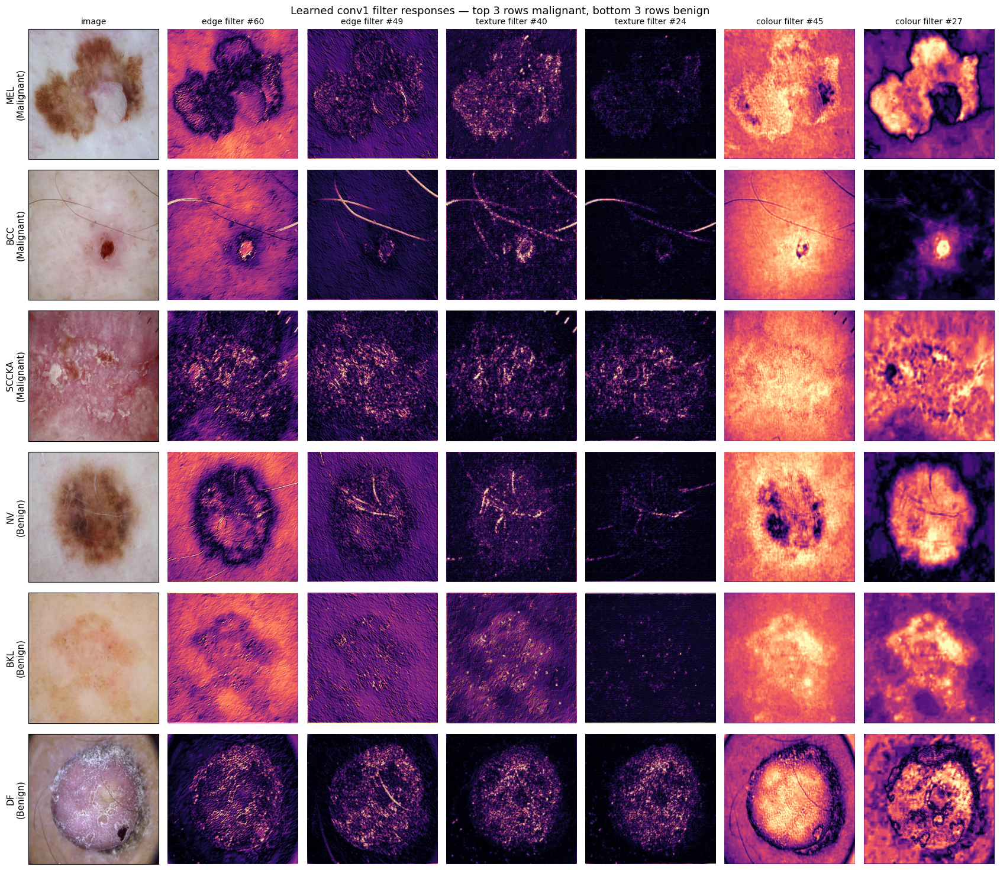

In [6]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def conv1_responses(rgb):
    """Apply all 64 learned conv1 filters to one RGB image -> array (64, H, W) of absolute responses."""
    x = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)
    x = (x - MEAN) / STD
    with torch.no_grad():
        y = F.conv2d(x, W, padding=3)          # same filters as the model, stride 1
    return y[0].abs().numpy()

responses = {iid: conv1_responses(img) for iid, img in images.items()}

show_ids = [CHOSEN["edge"][0], CHOSEN["edge"][1], CHOSEN["texture"][0], CHOSEN["texture"][1],
            CHOSEN["colour"][0], CHOSEN["colour"][1]]
show_kind = ["edge", "edge", "texture", "texture", "colour", "colour"]

fig, axes = plt.subplots(6, 7, figsize=(17, 15))
for r, ex in enumerate(examples.itertuples()):
    axes[r, 0].imshow(images[ex.isic_id]); axes[r, 0].set_ylabel(f"{ex.dx}\n({ex.group})", fontsize=11)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    for c, (fi, kind) in enumerate(zip(show_ids, show_kind), start=1):
        resp = responses[ex.isic_id][fi]
        axes[r, c].imshow(resp, cmap="magma", vmax=np.percentile(resp, 99.5)); axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(f"{kind} filter #{fi}", fontsize=10)
axes[0, 0].set_title("image", fontsize=10)
plt.suptitle("Learned conv1 filter responses — top 3 rows malignant, bottom 3 rows benign", fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / "filter_responses.png", dpi=110); plt.show()

### 1.4 Is the difference real or just these six images? (quantitative check)
Six images can be misleading, so I compute the **mean absolute response** of each chosen filter **inside
the image centre** (where the lesion usually is) on a larger random sample of malignant and benign lesions,
and compare the two groups.

Mean absolute filter response in the image centre (200 images):


group,Benign,Malignant,malignant / benign
edge #60,0.775,0.760,0.981
edge #49,0.373,0.334,0.895
edge #30,0.262,0.227,0.867
texture #40,0.114,0.094,0.823
texture #24,0.129,0.106,0.818
texture #39,0.150,0.124,0.829
colour #45,1.913,2.267,1.185
colour #27,1.758,1.812,1.031
colour #31,0.498,0.516,1.036


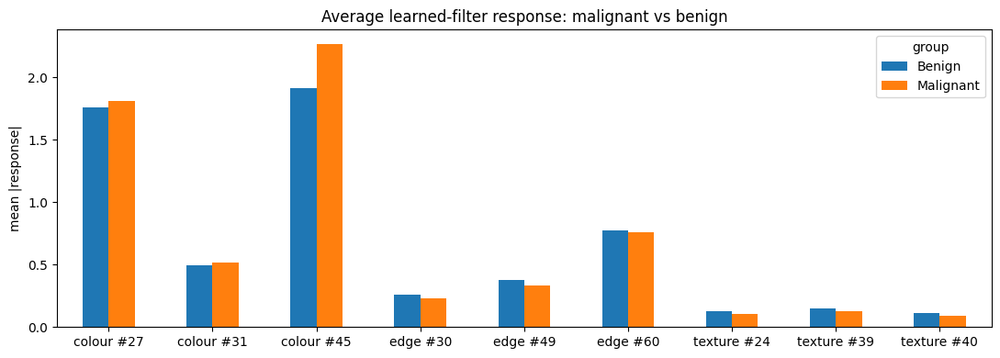

In [7]:
N_PER_GROUP = 100
sample = pd.concat([
    derm[derm["diagnosis_1"] == g].sample(min(N_PER_GROUP, (derm["diagnosis_1"] == g).sum()), random_state=SEED)
    for g in ["Malignant", "Benign"]])

def centre(a, frac=0.6):
    """Central crop (frac of each side), where the lesion usually is."""
    h, w = a.shape[-2:]; dh, dw = int(h * (1 - frac) / 2), int(w * (1 - frac) / 2)
    return a[..., dh:h - dh, dw:w - dw]

chosen_all = [i for ids in CHOSEN.values() for i in ids]
rows = []
for r in sample.itertuples():
    resp = centre(conv1_responses(load_rgb(r.isic_id, size=224)))
    rows.append({"group": r.diagnosis_1, **{f"{k} #{i}": resp[i].mean() for k, ids in CHOSEN.items() for i in ids}})
energy = pd.DataFrame(rows)

summary = energy.groupby("group").mean().T
summary["malignant / benign"] = summary["Malignant"] / summary["Benign"]
print(f"Mean absolute filter response in the image centre ({len(sample)} images):")
display(summary.round(3))

ax = energy.melt(id_vars="group").pivot_table(index="variable", columns="group", values="value").plot.bar(figsize=(11, 4))
ax.set_ylabel("mean |response|"); ax.set_xlabel(""); ax.set_title("Average learned-filter response: malignant vs benign")
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(FIG_DIR / "filter_energy.png", dpi=120); plt.show()

### Answer 1 — Do edges or textures look different between malignant and benign lesions?

**What the filters are.** The 64 learned `conv1` filters of ResNet-18 look like the hand-made filters from class:
oriented edge detectors (light/dark bands at different angles), high-frequency texture detectors (small
checkerboard/spot patterns) and colour-opponent blobs (e.g. pink vs green, blue vs orange). I picked 3 of each kind
automatically (edge #60, #49, #30; texture #40, #24, #39; colour #45, #27, #31).

**Visual comparison (six images, figure in 1.3).**
- **Borders (edge filters):** the melanoma (MEL) gives an irregular, multi-lobed outline with notches. The nevus
  (NV) gives a rounder, smoother and more continuous outline. The BCC lesion is very small, so the filter mostly
  outlines a tiny spot.
- **Texture inside the lesion:** the malignant SCCKA and the MEL show patchy, uneven texture responses (scales,
  irregular pigment). In the NV the interior is more uniform. But the benign **dermatofibroma (DF) is just as
  textured**, because of its white scaly surface. So "lots of texture" is not a malignancy sign on its own.
- **Artefacts dominate:** in the BCC and NV images the strongest edge/texture responses are on **hairs**, not on the
  lesion. Low-level filters respond to any strong line, whether or not it has a medical meaning.
- **Colour filters** separate the lesion from the surrounding skin best: colour #27 lights up the whole lesion area
  in almost every image.

**Quantitative check (100 malignant vs 100 benign dermoscopic images, table in 1.4).**
- The differences are **small**. The edge and texture filters respond slightly **less** in malignant lesions
  (malignant/benign ratio 0.82–0.98). Only colour filter #45 is clearly higher in malignant lesions (ratio 1.19).
- This is the opposite of what one might expect from melanoma alone. The reason is the class mix: about 70% of
  the malignant images in MILK10k are **BCC**, which are often small, pink and low-contrast. Most benign images are
  **NV and BKL**, which are pigmented and have a visible pigment network (lots of texture). Colour filter #45
  responds to pink/red tones, which fits the reddish BCC and SCC lesions.

**Conclusion.** There are visible differences: malignant lesions tend to have more **irregular borders** and
**uneven texture and colour**. But they are not consistent enough to separate the two groups with a single
first-layer filter. They depend on the diagnosis class, and hairs and lighting add a lot of noise. A single
first-layer filter only sees a 7×7 pixel patch. Recognising malignancy needs these simple responses to be
combined over larger regions (border shape, asymmetry, colour variety), which is what the deeper layers of a CNN
do.

*Limitations:* the filters were trained on ImageNet, not on skin images. The six example images are random, one
per class. The 200-image comparison is descriptive only (no statistical test).

---
## 2. Gaussian blur and the `sigma` parameter

### What `sigma` controls (from the `scipy.ndimage.gaussian_filter` documentation)

`gaussian_filter(input, sigma, order=0, mode='reflect', cval=0.0, truncate=4.0, *, radius=None, axes=None)`

- **`sigma` is the standard deviation of the Gaussian kernel, in pixels.** It sets how wide the bell curve
  is, i.e. how far around each pixel the averaging reaches. Bigger sigma = wider kernel = stronger blur.
- It can be **one number** (same in every axis) or **one value per axis** (e.g. `sigma=(5, 0)` blurs only
  vertically). `sigma=0` on an axis means no filtering along that axis.
- **Careful with colour images:** an RGB image has 3 axes (height, width, channel). A single number like
  `sigma=3` also blurs *across the colour channels*, mixing R, G and B. For colour images use
  `sigma=(s, s, 0)`.
- The kernel is cut off (`truncate`) at 4 standard deviations, so its **radius is `int(truncate*sigma + 0.5)`
  pixels** (sigma=2 → a 17×17 kernel). The documentation notes that the multidimensional filter is a
  sequence of 1-D filters, which is possible because the Gaussian is separable.
- In frequency terms, the Gaussian is a **low-pass filter**: a larger sigma removes finer details (higher
  spatial frequencies) and keeps only coarse structure.

### 2.1 The kernel itself for different sigmas

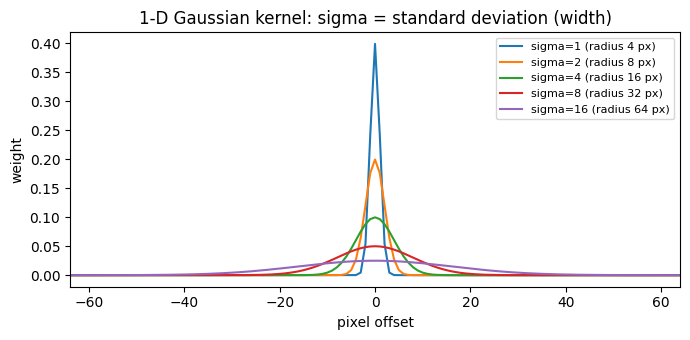

In [8]:
SIGMAS = [0, 1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(7, 3.5))
for s in SIGMAS[1:]:
    impulse = np.zeros(129); impulse[64] = 1
    k = ndi.gaussian_filter1d(impulse, s)        # filtering an impulse gives back the kernel
    ax.plot(np.arange(-64, 65), k, label=f"sigma={s} (radius {int(4 * s + 0.5)} px)")
ax.set_xlim(-64, 64); ax.set_xlabel("pixel offset"); ax.set_ylabel("weight")
ax.set_title("1-D Gaussian kernel: sigma = standard deviation (width)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "gaussian_kernels.png", dpi=120); plt.show()

### 2.2 Blurring a MILK10k image with different sigmas

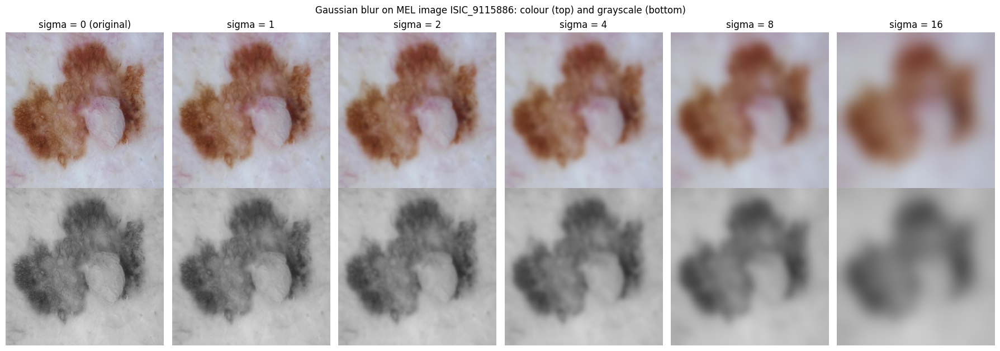

In [9]:
demo = examples.iloc[0]                       # the melanoma example
rgb = images[demo.isic_id]
gray = to_gray(rgb)

fig, axes = plt.subplots(2, len(SIGMAS), figsize=(18, 6.4))
for c, s in enumerate(SIGMAS):
    axes[0, c].imshow(np.clip(ndi.gaussian_filter(rgb, sigma=(s, s, 0)), 0, 1))
    axes[0, c].set_title(f"sigma = {s}"); axes[0, c].axis("off")
    axes[1, c].imshow(ndi.gaussian_filter(gray, sigma=s), cmap="gray", vmin=0, vmax=1); axes[1, c].axis("off")
axes[0, 0].set_title("sigma = 0 (original)")
plt.suptitle(f"Gaussian blur on {demo.dx} image {demo.isic_id}: colour (top) and grayscale (bottom)")
plt.tight_layout(); plt.savefig(FIG_DIR / "gaussian_sigmas.png", dpi=110); plt.show()

### 2.3 Measuring the effect
For each sigma I measure (a) how much fine detail is left (mean gradient magnitude) and (b) how much the
image changed from the original (mean absolute difference).

,sigma,mean gradient (detail left),mean |change| vs original,kernel size (px)
0,0.0,0.0857,0.0000,1
1,0.5,0.0785,0.0016,5
2,1.0,0.0641,0.0049,9
3,2.0,0.0493,0.0086,17
4,3.0,0.0423,0.0110,25
5,4.0,0.0381,0.0130,33
6,6.0,0.0329,0.0166,49
7,8.0,0.0297,0.0199,65
8,12.0,0.0257,0.0264,97
9,16.0,0.0228,0.0328,129


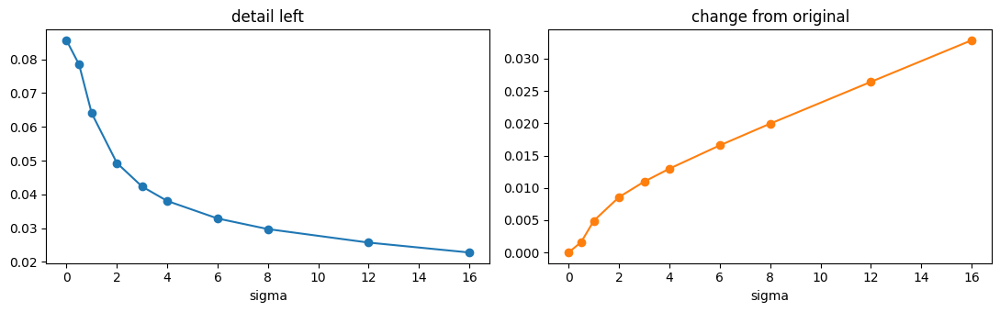

In [10]:
sigmas_fine = [0, 0.5, 1, 2, 3, 4, 6, 8, 12, 16]
def grad_mag(g):
    return np.hypot(ndi.sobel(g, axis=0), ndi.sobel(g, axis=1))

effect = pd.DataFrame([{"sigma": s,
                        "mean gradient (detail left)": grad_mag(ndi.gaussian_filter(gray, s)).mean(),
                        "mean |change| vs original": np.abs(ndi.gaussian_filter(gray, s) - gray).mean(),
                        "kernel size (px)": 2 * int(4 * s + 0.5) + 1}
                       for s in sigmas_fine])
display(effect.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(effect["sigma"], effect["mean gradient (detail left)"], "o-"); ax[0].set_title("detail left")
ax[1].plot(effect["sigma"], effect["mean |change| vs original"], "o-", color="C1"); ax[1].set_title("change from original")
for a in ax: a.set_xlabel("sigma")
plt.tight_layout(); plt.savefig(FIG_DIR / "gaussian_effect.png", dpi=120); plt.show()

### 2.4 Two practical side experiments
**(a)** A scalar sigma on an RGB array also blurs across the 3 colour channels (wrong for colour images).
**(b)** Different sigma per axis gives a directional (motion-like) blur.

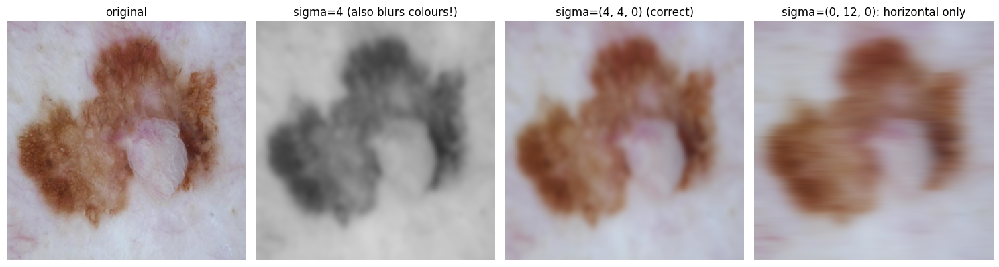

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(rgb); axes[0].set_title("original")
axes[1].imshow(np.clip(ndi.gaussian_filter(rgb, sigma=4), 0, 1)); axes[1].set_title("sigma=4 (also blurs colours!)")
axes[2].imshow(np.clip(ndi.gaussian_filter(rgb, sigma=(4, 4, 0)), 0, 1)); axes[2].set_title("sigma=(4, 4, 0) (correct)")
axes[3].imshow(np.clip(ndi.gaussian_filter(rgb, sigma=(0, 12, 0)), 0, 1)); axes[3].set_title("sigma=(0, 12, 0): horizontal only")
for a in axes: a.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "gaussian_side_experiments.png", dpi=110); plt.show()

### Answer 2 — What does sigma control, and what did I observe?

**What sigma controls.** `sigma` is the **standard deviation of the Gaussian kernel, in pixels**. It sets the width
of the bell curve, so it decides how far around each pixel the weighted averaging reaches. A larger sigma gives a
wider kernel, more averaging and a stronger blur. With the default `truncate=4.0` the kernel radius is
`int(4·sigma + 0.5)`: sigma = 1 → 9×9 px, sigma = 2 → 17×17 px, sigma = 16 → 129×129 px. sigma can be one value
for all axes or one value per axis, and `sigma = 0` means no smoothing along that axis. The Gaussian is a
**low-pass filter**, so sigma sets the scale below which details are removed.

**What I observed on the melanoma image (ISIC_9115886).**
- **sigma = 1–2:** noise and the finest details (skin texture, the finest pigment dots) disappear, but the
  pigment network and the lesion border are still sharp. The remaining detail (mean gradient) drops from 0.086
  to 0.064 at sigma = 1 (−25%) and to 0.049 at sigma = 2 (−42%).
- **sigma = 4:** the pigment network is gone. Only the large dark and light regions and the lesion outline
  remain (−56% detail).
- **sigma = 8–16:** only the overall shape of the lesion is left. At sigma = 16 the border is a smooth gradient
  and the notches of the outline are no longer visible (−73% detail). The change from the original keeps growing
  (mean |change| 0.005 at sigma = 1 → 0.033 at sigma = 16).
- Fine detail is lost fastest at small sigmas, and then more slowly.

**Two practical findings.**
1. On an RGB image, a single number (`sigma=4`) also blurs **across the 3 colour channels**, so the result loses
   its colour and looks almost grayscale. For colour images one must use `sigma=(4, 4, 0)`.
2. Different sigmas per axis (`sigma=(0, 12, 0)`) blur only horizontally, which looks like motion blur.

**Why it matters.** A small sigma (about 1–2) is a good denoising step before edge detection: it removes noise but
keeps the lesion border. A large sigma removes exactly the structures (pigment network, border irregularity) that
dermatologists use to judge malignancy.

---
## 3. Canny edge detection

The Canny detector (John Canny, 1986) was designed to find edges that are (1) real edges, not noise,
(2) well localised, and (3) one pixel thick with a single response per edge. It has 5 steps:

1. **Gaussian smoothing** to suppress noise (parameter `sigma`).
2. **Gradient** with Sobel filters: magnitude `sqrt(Gx² + Gy²)` and direction `atan2(Gy, Gx)`.
3. **Non-maximum suppression (NMS)**: keep a pixel only if its magnitude is the largest along the gradient
   direction (across the edge). This thins thick ridges to 1-pixel lines.
4. **Double threshold**: pixels above `high` are *strong* edges, between `low` and `high` *weak* edges,
   below `low` are discarded.
5. **Hysteresis**: keep weak pixels only if they are connected to a strong pixel. This keeps long continuous
   edges and removes isolated noise.

### 3.1 My implementation

In [12]:
def canny(image, sigma=2.0, low_ratio=0.1, high_ratio=0.2):
    """Canny edge detector written from scratch with NumPy/SciPy.

    image       : 2-D grayscale array (any range)
    sigma       : std of the Gaussian smoothing (step 1)
    low_ratio,
    high_ratio  : thresholds as a fraction of the largest gradient magnitude (step 4)
    returns     : boolean edge map, same shape as image
    """
    img = image.astype(np.float64)

    # 1. Gaussian smoothing
    smooth = ndi.gaussian_filter(img, sigma)

    # 2. Sobel gradients (axis=1 -> change along x, axis=0 -> change along y)
    gx = ndi.sobel(smooth, axis=1)
    gy = ndi.sobel(smooth, axis=0)
    mag = np.hypot(gx, gy)
    angle = np.rad2deg(np.arctan2(gy, gx)) % 180          # direction folded into [0, 180)

    # 3. Non-maximum suppression: compare each pixel with its 2 neighbours along the gradient,
    #    using the direction rounded to 0, 45, 90 or 135 degrees.
    H, W = mag.shape
    padded = np.pad(mag, 1)
    def neighbour(dy, dx):
        return padded[1 + dy:1 + dy + H, 1 + dx:1 + dx + W]
    sector = np.round(angle / 45).astype(int) % 4         # 0:0°, 1:45°, 2:90°, 3:135°
    offsets = {0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (1, -1)}    # (dy, dx) for each direction (rows go down)
    keep = np.zeros_like(mag, dtype=bool)
    for s, (dy, dx) in offsets.items():
        is_max = (mag >= neighbour(dy, dx)) & (mag >= neighbour(-dy, -dx))
        keep |= (sector == s) & is_max
    thin = np.where(keep, mag, 0.0)

    # 4. Double threshold
    high = high_ratio * thin.max()
    low = low_ratio * thin.max()
    strong = thin >= high
    weak_or_strong = thin >= low

    # 5. Hysteresis: a connected group of candidate pixels survives if it contains at least one strong pixel
    labels, n = ndi.label(weak_or_strong, structure=np.ones((3, 3)))    # 8-connectivity
    has_strong = np.zeros(n + 1, dtype=bool)
    has_strong[np.unique(labels[strong])] = True
    has_strong[0] = False
    return has_strong[labels]


def sobel_edges(image, sigma=2.0, threshold_ratio=0.2):
    """Sobel baseline: gradient magnitude, and a simple single threshold on it."""
    smooth = ndi.gaussian_filter(image.astype(np.float64), sigma)
    mag = np.hypot(ndi.sobel(smooth, axis=1), ndi.sobel(smooth, axis=0))
    return mag, mag >= threshold_ratio * mag.max()

### 3.2 Sanity check on a synthetic image
A bright square with noise: Canny should give a clean, 1-pixel-thick outline of about 4 × 64 = 256 pixels.

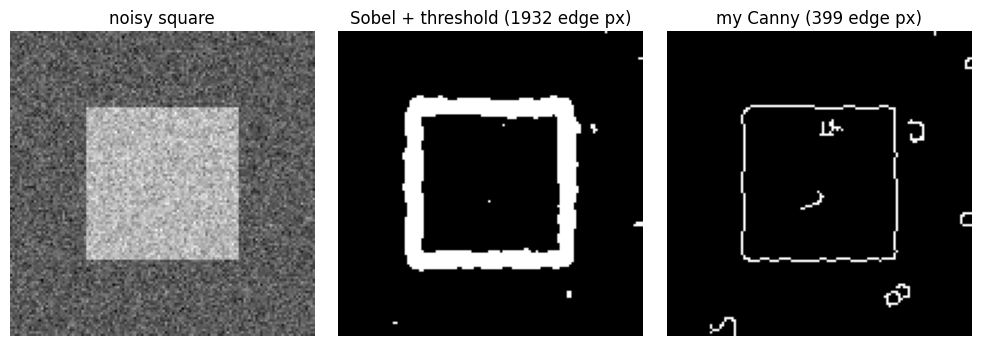

perimeter of the square ≈ 256 pixels


In [13]:
rng = np.random.default_rng(0)
square = np.zeros((128, 128)); square[32:96, 32:96] = 1
noisy = square + rng.normal(0, 0.25, square.shape)
mine = canny(noisy, sigma=2)
_, sob = sobel_edges(noisy, sigma=2)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(noisy, cmap="gray"); axes[0].set_title("noisy square")
axes[1].imshow(sob, cmap="gray"); axes[1].set_title(f"Sobel + threshold ({sob.sum()} edge px)")
axes[2].imshow(mine, cmap="gray"); axes[2].set_title(f"my Canny ({mine.sum()} edge px)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()
print("perimeter of the square ≈", 4 * 64, "pixels")

### 3.3 Canny vs Sobel on a MILK10k image

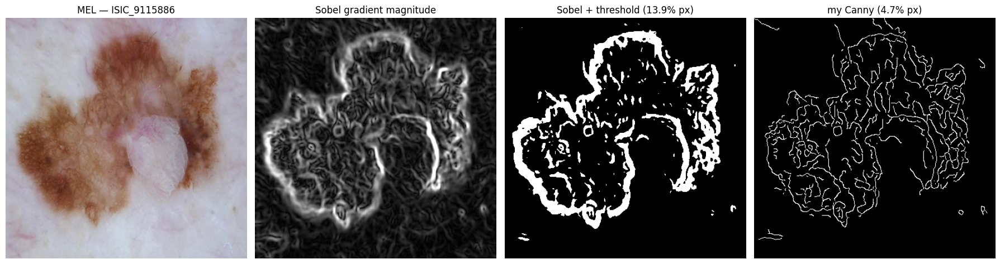

In [14]:
edge_demo = examples.iloc[0]                  # same melanoma example as above
g = to_gray(images[edge_demo.isic_id])

canny_map = canny(g, sigma=2.0, low_ratio=0.1, high_ratio=0.2)
sobel_mag, sobel_map = sobel_edges(g, sigma=2.0, threshold_ratio=0.2)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(images[edge_demo.isic_id]); axes[0].set_title(f"{edge_demo.dx} — {edge_demo.isic_id}")
axes[1].imshow(sobel_mag, cmap="gray", vmax=np.percentile(sobel_mag, 99.5)); axes[1].set_title("Sobel gradient magnitude")
axes[2].imshow(sobel_map, cmap="gray"); axes[2].set_title(f"Sobel + threshold ({sobel_map.mean()*100:.1f}% px)")
axes[3].imshow(canny_map, cmap="gray"); axes[3].set_title(f"my Canny ({canny_map.mean()*100:.1f}% px)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "canny_vs_sobel.png", dpi=110); plt.show()

A zoom on the centre makes the line thickness difference visible.

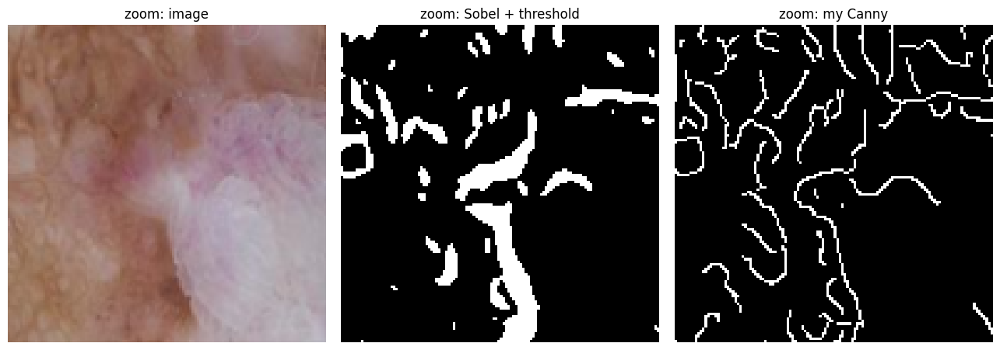

In [15]:
h, w = g.shape; z = (slice(h // 3, 2 * h // 3), slice(w // 3, 2 * w // 3))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(images[edge_demo.isic_id][z]); axes[0].set_title("zoom: image")
axes[1].imshow(sobel_map[z], cmap="gray", interpolation="nearest"); axes[1].set_title("zoom: Sobel + threshold")
axes[2].imshow(canny_map[z], cmap="gray", interpolation="nearest"); axes[2].set_title("zoom: my Canny")
for a in axes: a.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "canny_vs_sobel_zoom.png", dpi=110); plt.show()

### 3.4 Effect of Canny's parameters

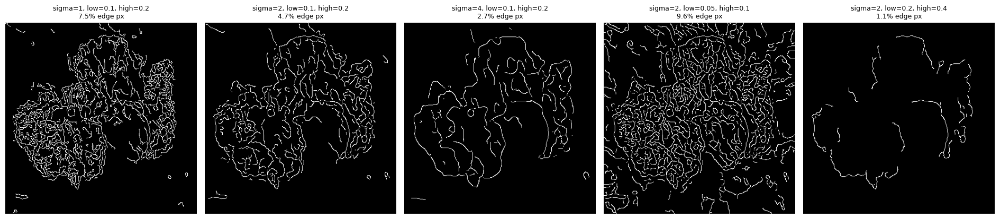

In [16]:
settings = [(1, 0.1, 0.2), (2, 0.1, 0.2), (4, 0.1, 0.2), (2, 0.05, 0.1), (2, 0.2, 0.4)]
fig, axes = plt.subplots(1, len(settings), figsize=(19, 4))
for ax, (s, lo, hi) in zip(axes, settings):
    e = canny(g, sigma=s, low_ratio=lo, high_ratio=hi)
    ax.imshow(e, cmap="gray"); ax.set_title(f"sigma={s}, low={lo}, high={hi}\n{e.mean()*100:.1f}% edge px", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "canny_params.png", dpi=110); plt.show()

### Answer 3 — Main differences between Canny and Sobel

Both were applied to the melanoma image ISIC_9115886 with the same smoothing (sigma = 2) and a threshold of 20% of
the maximum gradient. Canny also uses a low threshold of 10%.

1. **Line thickness.** Sobel gives **thick bands** of edge pixels: 13.9% of the image is marked as edge. Canny
   gives **1-pixel-thin lines** (4.7% of pixels), thanks to non-maximum suppression. On the synthetic square
   (true perimeter ≈ 256 px), Sobel marked 1,932 pixels (a band about 7 px wide) and my Canny marked 399.
2. **Output type.** Sobel gives a continuous **gradient magnitude** (and direction) map. To get edges it needs a
   single threshold, chosen by hand. Canny gives a clean **binary** edge map.
3. **Weak edges and noise.** With one threshold, Sobel either keeps noise (low threshold) or breaks edges apart
   (high threshold). Canny's double threshold with hysteresis keeps weak edge pixels **only if they are connected
   to a strong edge**. This gives long, continuous contours and removes most isolated spots.
4. **What gets detected on the lesion.** The Sobel threshold mostly marks the **outer border** of the lesion as a
   thick band. Canny traces the border but also **many internal edges**: the pigment network and the boundaries
   between light and dark areas inside the melanoma. This is more detail than needed if the goal is the lesion
   outline.
5. **Parameters.** Canny is more sensitive to its settings. Increasing sigma from 1 to 4 reduces the edge pixels
   from 7.5% to 2.7% and leaves only the large outlines. Lowering the thresholds (0.05/0.10) gives 9.6% (texture
   and skin noise). Raising them (0.20/0.40) gives 1.1% (only fragments of the border). Sobel has fewer settings
   and is simpler and faster.

**Summary.** Canny gives thinner, cleaner and better connected edges than Sobel. But on dermoscopy images
neither method gives a clean, closed lesion boundary: both also react to the pigment network, hairs and skin
texture. Separating the lesion from the skin would need a segmentation method, not only an edge detector.